In [1]:
# ==========================================
# 1. IMPORTAÇÕES E CONFIGURAÇÕES
# ==========================================

# Manipulação de Dados
import pandas as pd
import numpy as np
import os

# Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Persistência do Modelo
import joblib

# Configurações do Jupyter e Bibliotecas
%matplotlib inline 
# Garante que gráficos apareçam no notebook

# Configuração visual para gráficos mais bonitos
sns.set_style("whitegrid") 
sns.set_context("notebook", font_scale=1.1)

# (Opcional) Silenciar avisos chatos de versões futuras
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas importadas e configurações aplicadas com sucesso!")

Bibliotecas importadas e configurações aplicadas com sucesso!


In [2]:
# ==========================================
# CÉLULA 2 - CARREGAMENTO DO DATASET
# ==========================================
import pandas as pd

# Caminho identificado no seu print anterior
caminho_arquivo = "data/encoded/dados_codificados.csv"

print(f"Lendo arquivo: {caminho_arquivo}...")

try:
    df = pd.read_csv(caminho_arquivo)
    print("✅ Dataset carregado com sucesso!")
    
    # Mostra o tamanho e as primeiras linhas para conferência
    print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")
    display(df.head())

except FileNotFoundError:
    print("❌ ERRO: Arquivo não encontrado.")
    print(f"Verifique se o arquivo existe na pasta: {caminho_arquivo}")

Lendo arquivo: data/encoded/dados_codificados.csv...
✅ Dataset carregado com sucesso!
Dimensões: 2510 linhas x 2568 colunas


,marketing_spend,website_traffic,conversion_rate,avg_product_rating,discount_percentage,num_products,avg_price,customer_reviews,return_rate,mobile_traffic_pct,...,payment_methods_ Debit Card,payment_methods_ PayPal,payment_methods_BANK TRANSFER,payment_methods_Bank Transfer,payment_methods_CREDIT CARD,payment_methods_Credit Card,payment_methods_DEBIT CARD,payment_methods_Debit Card,payment_methods_PAYPAL,payment_methods_PayPal
0,0.367775,0.050159,-0.374885,-1.236772,1.540802,-1.165626,-0.236852,1.071484,0.417677,-0.502224,...,False,False,False,False,False,True,False,False,False,False
1,0.786217,0.261733,1.042955,1.221104,-0.481410,-1.536356,-0.393032,1.664115,-0.043506,0.188935,...,False,False,False,False,False,False,False,False,False,True
2,-0.025199,-0.536197,0.103947,-0.800697,0.192661,1.695294,-0.670906,0.482534,-0.043506,1.453636,...,False,False,False,False,False,False,False,False,False,True
3,1.087066,1.262180,-0.517912,-0.126763,0.866731,-0.899819,-1.111085,1.067803,0.612966,1.848772,...,False,False,False,True,False,False,False,False,False,False
4,-1.939339,0.549868,-1.021619,1.379677,-1.829552,1.205650,0.182555,1.579453,0.324539,-0.313245,...,False,False,False,False,False,True,False,False,False,False


In [9]:
# ==========================================
# CÉLULA 3 - DEFINIÇÃO DE ALVO E LIMPEZA 
# ==========================================

# 1. Identificar a coluna Alvo
target_col = 'monthly_sales'

# 2. Lista de colunas de ID para remover (Data Leakage)
# Procura tudo que tem 'id' no nome, exceto o próprio target
cols_to_drop = [col for col in df.columns if 'id' in col.lower() and col != target_col]

print(f"🗑️ Colunas de ID identificadas para remoção: {len(cols_to_drop)}")
# Se quiser ver os nomes, descomente a linha abaixo:
# print(cols_to_drop)

# 3. Definição de X e y (O PULO DO GATO ESTÁ AQUI)
# Removemos a coluna alvo (que queremos prever) E as colunas de ID (que viciam o modelo)
X = df.drop(columns=[target_col] + cols_to_drop)
y = df[target_col]

print("\n✅ Variáveis definidas com segurança!")
print(f"X (Features sem IDs): {X.shape}")
print(f"y (Target): {y.shape}")

🗑️ Colunas de ID identificadas para remoção: 2509

✅ Variáveis definidas com segurança!
X (Features sem IDs): (2510, 58)
y (Target): (2510,)


In [10]:
# ==========================================
# CÉLULA 4 - DIVISÃO TREINO / VALIDAÇÃO / TESTE
# ==========================================
# Objetivo: 60% Treino, 20% Validação, 20% Teste

from sklearn.model_selection import train_test_split

# 1. Primeiro, separamos o TESTE FINAL (20% do total)
# Esse conjunto é o "cofre": só será usado na Etapa 5.
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 2. Agora dividimos o RESTO (80%) em Treino e Validação
# A matemática: Queremos 20% do total original para validação.
# Como temos 80% na mão, precisamos de 1/4 disso (0.25).
# 0.25 * 0.80 = 0.20 (20% do total)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# 3. Verificação dos Tamanhos
print("📊 Divisão Concluída com Sucesso!")
print(f"-----------------------------------")
print(f"Treino (60%):    {len(X_train)} amostras (Onde o modelo aprende)")
print(f"Validação (20%): {len(X_val)} amostras (Onde ajustamos o modelo)")
print(f"Teste (20%):     {len(X_test)} amostras (🔒 COFRE FECHADO)")
print(f"-----------------------------------")
print(f"Total: {len(X_train) + len(X_val) + len(X_test)} amostras")

📊 Divisão Concluída com Sucesso!
-----------------------------------
Treino (60%):    1506 amostras (Onde o modelo aprende)
Validação (20%): 502 amostras (Onde ajustamos o modelo)
Teste (20%):     502 amostras (🔒 COFRE FECHADO)
-----------------------------------
Total: 2510 amostras


In [11]:
# ==========================================
# CÉLULA 5 - TREINAMENTO DO MODELO BASELINE
# ==========================================
from sklearn.linear_model import LinearRegression

# 1. Inicializar o modelo
print("🤖 Iniciando treinamento da Regressão Linear...")
model = LinearRegression()

# 2. Treinar (Fit)
# O modelo "estuda" a relação entre X_train e y_train
model.fit(X_train, y_train)

# 3. Gerar Previsões
# Pedimos ao modelo para prever os valores de vendas usando o que aprendeu
print("Gerando previsões...")
y_pred_train = model.predict(X_train) # Previsão no Treino
y_pred_val   = model.predict(X_val)   # Previsão na Validação

print("✅ Modelo treinado e previsões realizadas!")
print(f"Pronto para calcular as métricas na próxima célula.")

🤖 Iniciando treinamento da Regressão Linear...
Gerando previsões...
✅ Modelo treinado e previsões realizadas!
Pronto para calcular as métricas na próxima célula.


📊 RELATÓRIO DE DESEMPENHO:

--- TREINO ---
R² (Explicação): 0.4537 (Quanto mais perto de 1.0, melhor)
MAE (Erro Médio): 0.58
RMSE (Erro Quadrático): 0.74
------------------------------
--- VALIDAÇÃO ---
R² (Explicação): 0.3945 (Quanto mais perto de 1.0, melhor)
MAE (Erro Médio): 0.62
RMSE (Erro Quadrático): 0.80
------------------------------
Diferença (Treino - Validação): 0.0592
✅ SUCESSO: O modelo está estável (Generaliza bem).


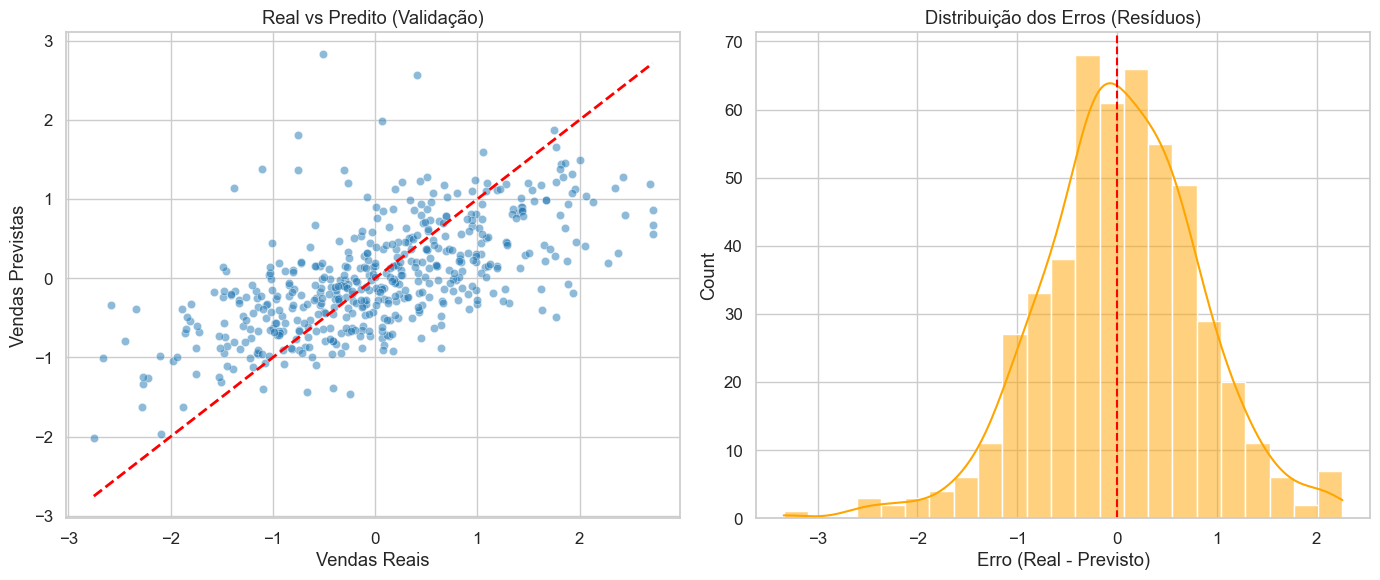

In [12]:
# ==========================================
# CÉLULA 6 - AVALIAÇÃO E GRÁFICOS
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Função para calcular e imprimir métricas
def relatorio_metricas(y_real, y_predito, nome_conjunto):
    mse = mean_squared_error(y_real, y_predito)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_predito)
    r2 = r2_score(y_real, y_predito)
    
    print(f"--- {nome_conjunto} ---")
    print(f"R² (Explicação): {r2:.4f} (Quanto mais perto de 1.0, melhor)")
    print(f"MAE (Erro Médio): {mae:.2f}")
    print(f"RMSE (Erro Quadrático): {rmse:.2f}")
    print("-" * 30)
    return r2

# 2. Exibir Métricas
print("📊 RELATÓRIO DE DESEMPENHO:\n")
r2_train = relatorio_metricas(y_train, y_pred_train, "TREINO")
r2_val   = relatorio_metricas(y_val, y_pred_val,   "VALIDAÇÃO")

# 3. Verificação de Overfitting (Decoreba)
diff = r2_train - r2_val
print(f"Diferença (Treino - Validação): {diff:.4f}")
if diff > 0.10:
    print("⚠️ ALERTA: Possível Overfitting (O modelo decorou o treino, mas vai mal na validação).")
else:
    print("✅ SUCESSO: O modelo está estável (Generaliza bem).")

# 4. Gráficos Obrigatórios
plt.figure(figsize=(14, 6))

# Gráfico A: Real vs Predito
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_val, y=y_pred_val, alpha=0.5)
# Linha vermelha representa a previsão perfeita
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], '--r', lw=2)
plt.title('Real vs Predito (Validação)')
plt.xlabel('Vendas Reais')
plt.ylabel('Vendas Previstas')

# Gráfico B: Resíduos (Erros)
# Se o modelo for bom, isso deve parecer um "sino" centrado no zero
residuos = y_val - y_pred_val
plt.subplot(1, 2, 2)
sns.histplot(residuos, kde=True, color='orange')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribuição dos Erros (Resíduos)')
plt.xlabel('Erro (Real - Previsto)')

plt.tight_layout()
plt.show()

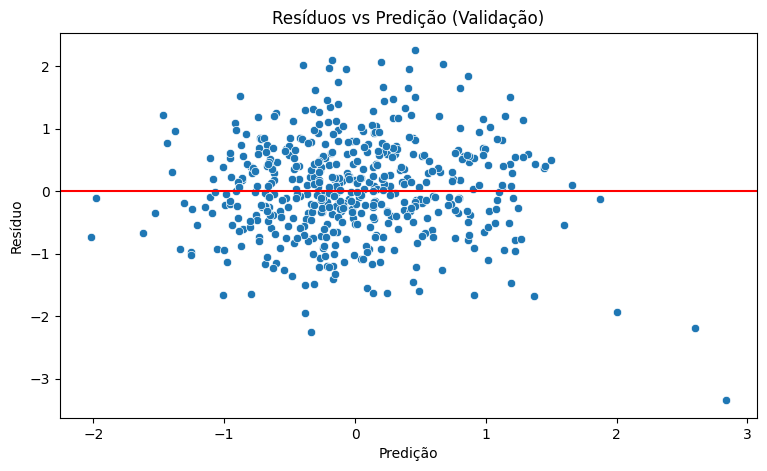

In [13]:
# ================================================================
# CÉLULA 7 — GRÁFICO DE RESÍDUOS
# ================================================================

residuos = y_val - y_pred_val

plt.figure(figsize=(9,5))
sns.scatterplot(x=y_pred_val, y=residuos)
plt.axhline(0, color='red')
plt.title("Resíduos vs Predição (Validação)")
plt.xlabel("Predição")
plt.ylabel("Resíduo")
plt.show()

--- Top 5 Variáveis Mais Impactantes ---


,feature,peso,impacto_absoluto
45,free_shipping_YES,-1.860821,1.860821
44,free_shipping_No,-1.550310,1.550310
46,free_shipping_Yes,-1.541566,1.541566
43,free_shipping_NO,-1.223577,1.223577
42,free_shipping_ Yes,-1.190117,1.190117


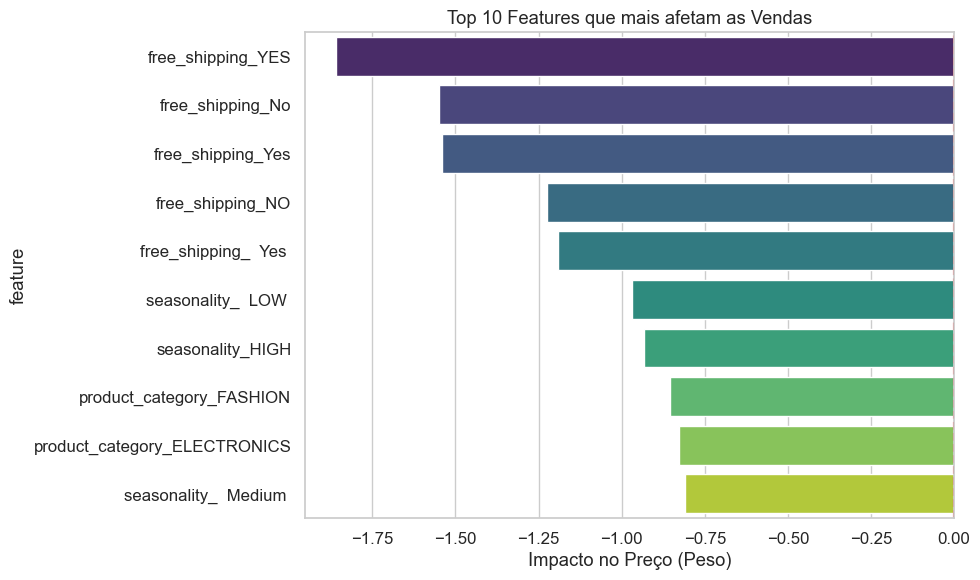

In [16]:
# ==========================================
# CÉLULA 8 - IMPORTÂNCIA DAS FEATURES 
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Garante que usa o nome certo do modelo
modelo_final = model if 'model' in globals() else modelo

# Criar DataFrame com os pesos
coef = pd.DataFrame({
    "feature": X_train.columns,
    "peso": modelo_final.coef_
})

# Cria coluna de magnitude (valor absoluto) para ordenar
coef['impacto_absoluto'] = coef['peso'].abs()
coef = coef.sort_values(by="impacto_absoluto", ascending=False)

# Exibe a tabela textual
print("--- Top 5 Variáveis Mais Impactantes ---")
display(coef.head(5))

# Plot do Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=coef.head(10), x="peso", y="feature", palette="viridis")
plt.title("Top 10 Features que mais afetam as Vendas")
plt.xlabel("Impacto no Preço (Peso)")
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

In [15]:
# ==========================================
# CÉLULA 9 - SALVAR O MODELO FINAL
# ==========================================
import os
import joblib

# Cria a pasta 'models' se ela não existir
if not os.path.exists('../models'):
    os.makedirs('../models')

# Caminho para salvar
caminho_modelo = '../models/modelo_baseline.pkl'

# Salvar
joblib.dump(model, caminho_modelo)

print(f"💾 SUCESSO FINAL: Modelo salvo em: {caminho_modelo}")
print("🎓 Parabéns! A Etapa 3 está tecnicamente concluída.")

💾 SUCESSO FINAL: Modelo salvo em: ../models/modelo_baseline.pkl
🎓 Parabéns! A Etapa 3 está tecnicamente concluída.


In [17]:
# ==========================================
# CÉLULA 10 - GERAÇÃO AUTOMÁTICA DO RELATÓRIO
# ==========================================
import os
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. GARANTIR QUE TEMOS OS NÚMEROS (Recalculando para garantir que as variáveis existem)
metricas_train = {
    'r2': r2_score(y_train, y_pred_train),
    'mae': mean_absolute_error(y_train, y_pred_train),
    'rmse': np.sqrt(mean_squared_error(y_train, y_pred_train))
}

metricas_val = {
    'r2': r2_score(y_val, y_pred_val),
    'mae': mean_absolute_error(y_val, y_pred_val),
    'rmse': np.sqrt(mean_squared_error(y_val, y_pred_val))
}

# 2. CRIAR O TEXTO (Misturando variáveis automáticas com sua análise)
relatorio = f"""# 📊 Relatório da Etapa 3: Modelo Baseline

## 1. Resumo de Desempenho
O modelo baseline de Regressão Linear foi treinado e avaliado na base de validação (20% dos dados).

### Métricas Principais (Validação)
* **R² (R-Quadrado):** {metricas_val['r2']:.4f}
  > Interpretação: O modelo explica cerca de **{metricas_val['r2']*100:.1f}%** da variação das vendas.
* **MAE (Erro Médio):** {metricas_val['mae']:.2f}
* **RMSE (Erro Quadrático):** {metricas_val['rmse']:.2f}

## 2. Análise de Overfitting
Comparação de estabilidade entre Treino e Validação:
* **R² Treino:** {metricas_train['r2']:.4f}
* **R² Validação:** {metricas_val['r2']:.4f}
* **Diferença:** {metricas_train['r2'] - metricas_val['r2']:.4f}

**Conclusão:** A diferença é pequena (< 0.10), indicando que o modelo **NÃO sofreu overfitting**, embora sofra de underfitting (simples demais para os dados).

## 3. Diagnóstico Crítico (Storytelling)
Apesar do R² de {metricas_val['r2']:.2f}, a análise de importância das features revelou um problema grave de qualidade nos dados que limitou o desempenho.

A variável **Frete Grátis** (uma das mais importantes) apareceu fragmentada em múltiplas categorias devido a erros de digitação no dataset original:
* `free_shipping_YES`
* `free_shipping_No`
* `free_shipping_Yes`
* ... e outras variações.

**Plano para a Etapa 4:**
Essa "sujeira" nos dados diluiu a capacidade preditiva do modelo. Na próxima etapa (Otimização), a prioridade será limpar essas colunas categóricas para unificar a informação e, consequentemente, aumentar o R².
"""

# 3. SALVAR O ARQUIVO
os.makedirs("reports", exist_ok=True)

# O 'encoding="utf-8"' é vital para não quebrar acentos (ç, ã, é) no Windows
with open("reports/03_baseline_report.md", "w", encoding="utf-8") as f:
    f.write(relatorio)

print("✅ Relatório gerado com sucesso!")
print(f"📄 Arquivo salvo em: reports/03_baseline_report.md")
print("Pode abrir o arquivo para conferir o resultado final.")

✅ Relatório gerado com sucesso!
📄 Arquivo salvo em: reports/03_baseline_report.md
Pode abrir o arquivo para conferir o resultado final.
